<a href="https://colab.research.google.com/github/baqueroxiomy-design/intro-ciencia-datos/blob/main/Regresi%C3%B3n_Lineal_TrabajoFinal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **REGRESIÓN LINEAL**

In [322]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer, MissingIndicator
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler, MinMaxScaler, RobustScaler, PolynomialFeatures
from sklearn.neighbors import KNeighborsRegressor

df = pd.read_csv('//content/df (1).csv')
df

,area_construida_m2,m2_por_habitacion,banos,habitaciones,pisos,zona,anio_construccion,vista,precio
0,124.49002,41.5,1.50,3.0,1.5,Norte,1955,0,313000.00
1,339.09595,67.8,2.50,5.0,2.0,Seattle,1921,4,2384000.00
2,179.30279,59.8,2.00,3.0,1.0,Sur,1966,0,342000.00
3,185.80600,61.9,2.25,3.0,1.0,Eastside,1963,0,420000.00
4,180.23182,45.1,2.50,4.0,1.0,Eastside,1976,0,550000.00
...,...,...,...,...,...,...,...,...,...
4541,140.28353,46.8,1.75,3.0,1.0,Seattle,1954,0,308166.67
4542,135.63838,45.2,2.50,3.0,2.0,Eastside,1983,0,534333.33
4543,279.63803,93.2,2.50,3.0,2.0,Sur,2009,0,416904.17
4544,194.16727,48.5,2.00,4.0,1.0,Seattle,1974,0,203400.00


**EXPLORACIÓN**

In [323]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4546 entries, 0 to 4545
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   area_construida_m2  4546 non-null   float64
 1   m2_por_habitacion   4544 non-null   float64
 2   banos               4544 non-null   float64
 3   habitaciones        4544 non-null   float64
 4   pisos               4546 non-null   float64
 5   zona                4546 non-null   object 
 6   anio_construccion   4546 non-null   int64  
 7   vista               4546 non-null   int64  
 8   precio              4546 non-null   float64
dtypes: float64(6), int64(2), object(1)
memory usage: 319.8+ KB


In [324]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
area_construida_m2,4546.0,198.160219,88.816537,34.37411,135.63838,183.01891,242.47683,1.257907e+03
m2_por_habitacion,4544.0,58.266989,20.022756,15.20000,44.30000,54.30000,68.30000,1.988000e+02
banos,4544.0,2.156360,0.775357,0.75000,1.75000,2.25000,2.50000,8.000000e+00
habitaciones,4544.0,3.396347,0.902119,1.00000,3.00000,3.00000,4.00000,9.000000e+00
pisos,4546.0,1.512538,0.538565,1.00000,1.00000,1.50000,2.00000,3.500000e+00
anio_construccion,4546.0,1970.804883,29.769721,1900.00000,1951.00000,1976.00000,1997.00000,2.014000e+03
vista,4546.0,0.234932,0.765754,0.00000,0.00000,0.00000,0.00000,4.000000e+00
precio,4546.0,549328.793876,367385.109569,80000.00000,326446.42750,465000.00000,657400.00000,7.062500e+06


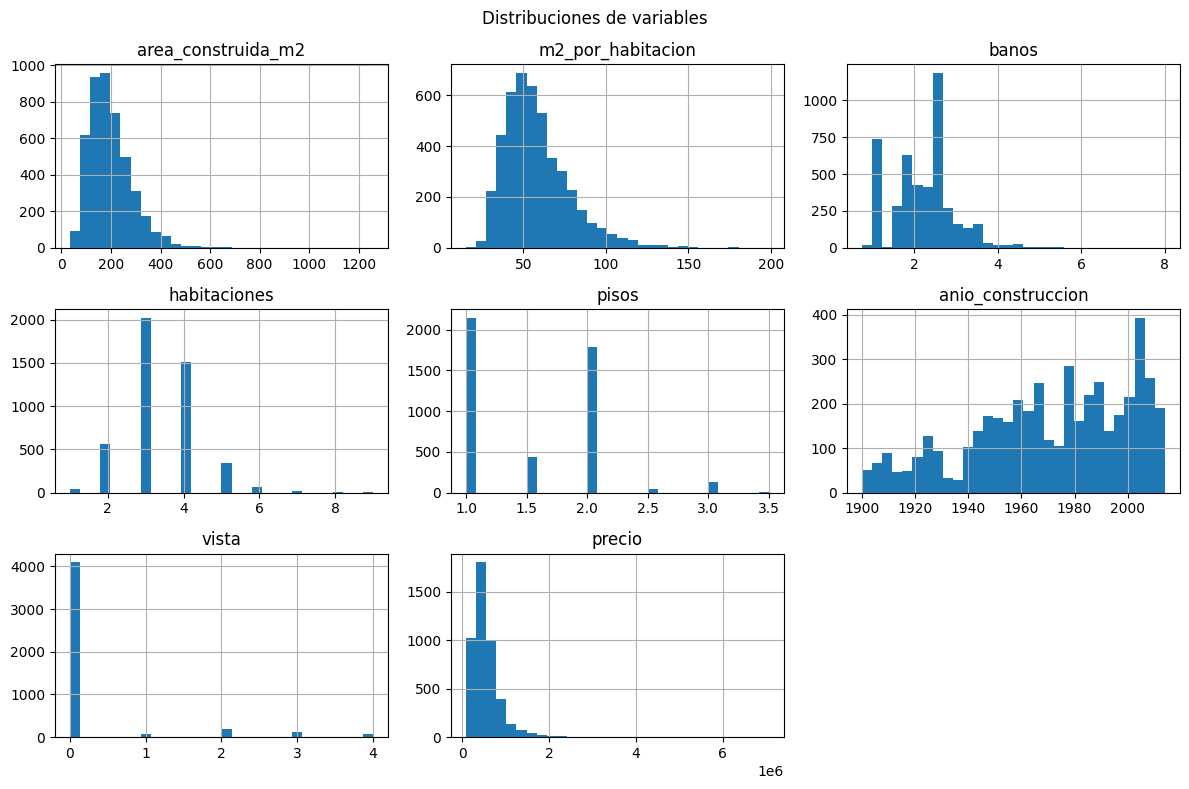

In [325]:
df[['area_construida_m2', 'm2_por_habitacion','banos','habitaciones', 'pisos', 'zona', 'anio_construccion', 'vista', 'precio']].hist(figsize=(12, 8), bins=30)
plt.suptitle('Distribuciones de variables')
plt.tight_layout()
plt.show()

**DEFINIR VARIABLES**

In [326]:
categoricas = ['zona',"vista"]
df['zona'] = df['zona'].astype('category')

df['vista'] =pd.Categorical(
    df['vista'],
    categories=[0, 1, 2, 3, 4],
    ordered=True
    )

In [327]:
X = df.drop(columns='precio')
y = df['precio']

num_cols = ['area_construida_m2', 'm2_por_habitacion', 'banos', 'habitaciones', 'pisos', 'anio_construccion' ]
nom_cols = ['zona']
ord_cols = ['vista']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)
X_train.shape, X_test.shape

((3409, 8), (1137, 8))

# **PREPROCESADORES**

### **IMPUTADORES**

**SimpleImputer + Median**

In [328]:
num_mod = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

nom_mod = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first'
    ))
])

ord_mod = Pipeline(steps=[
    ('ordinal', OrdinalEncoder(categories=[[0,1,2,3,4]]))
])

preprocess= ColumnTransformer(transformers=[
    ('num', num_mod , num_cols),
    ('nom', nom_mod, nom_cols),
    ('ord', ord_mod, ord_cols)
])

model_med= Pipeline(steps=[
    ('preprocess', preprocess),
    ('model', LinearRegression())
])

model_med.fit(X_train, y_train)
y_pred_test = model_med.predict(X_test)

**SimpleImputer + Mean**

In [329]:
num_mod_mean = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

preprocess_mean = ColumnTransformer(transformers=[
    ('num', num_mod_mean, num_cols),
    ('nom', nom_mod, nom_cols),
    ('ord', ord_mod, ord_cols)
])

model_mean = Pipeline(steps=[
    ('preprocess', preprocess_mean),
    ('model', LinearRegression())
])

model_mean.fit(X_train, y_train)
y_pred_mean = model_mean.predict(X_test)

**KNNImputer**

In [330]:
num_mod_knn = Pipeline(steps=[
    ('imputer', KNNImputer(n_neighbors=5, weights='distance')),
    ('scaler', StandardScaler())
])

preprocess_knn = ColumnTransformer(transformers=[
    ('num', num_mod_knn, num_cols),
    ('nom', nom_mod, nom_cols),
    ('ord', ord_mod, ord_cols)
])

model_knn = Pipeline(steps=[
    ('preprocess', preprocess_knn),
    ('model', LinearRegression())
])

model_knn.fit(X_train, y_train)
y_pred_knn = model_knn.predict(X_test)

**Métricas de imputaciones**

In [331]:
modelo_imp = {
    'Mean': model_mean,
    'Median': model_med,
    'KNN': model_knn,
}

resultados_imputacion = []

for nombre, modelo in modelo_imp.items():

    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    resultados_imputacion.append({
        'Imputador': nombre,
        'MAE': mae,
        'RMSE': rmse,
        'R2': r2
    })

resultados_imputacion = pd.DataFrame(resultados_imputacion)

resultados_imputacion

,Imputador,MAE,RMSE,R2
0,Mean,130019.241214,205737.869314,0.607956
1,Median,130069.975750,205853.821358,0.607514
2,KNN,129663.591095,205352.208318,0.609424


Se compararon tres estrategias de imputación para las variables numéricas con valores faltantes: media, mediana y KNN. Los resultados obtenidos fueron similares entre las tres alternativas. Sin embargo, KNNImputer con 5 vecinos presentó el mejor desempeño global, obteniendo el menor MAE (129.663,59) y el menor RMSE (205.352,21), además del mayor R² (0,609424). Por esta razón, se selecciona KNNImputer como estrategia de imputación para continuar con el proceso de modelado.

### **ESCALADORES CON KNN**

**StandardScaler**

In [332]:
num_mod_stand = Pipeline(steps=[
    ('imputer', KNNImputer(n_neighbors=5)),
    ('scaler', StandardScaler())
])

preprocess_stand = ColumnTransformer(transformers=[
    ('num', num_mod_stand, num_cols),
    ('nom', nom_mod, nom_cols),
    ('ord', ord_mod, ord_cols)
    ])

model_stand = Pipeline(steps=[
    ('preprocess', preprocess_stand),
    ('model', LinearRegression())
])

model_stand.fit(X_train, y_train)
y_pred_stand = model_stand.predict(X_test)

**MinMaxScaler**

In [333]:
num_mod_minmax = Pipeline(steps=[
    ('imputer', KNNImputer(n_neighbors=5)),
    ('scaler', MinMaxScaler())
])

preprocess_minmax = ColumnTransformer(transformers=[
    ('num', num_mod_minmax, num_cols),
    ('nom', nom_mod, nom_cols),
    ('ord', ord_mod, ord_cols)
])

model_minmax = Pipeline(steps=[
    ('preprocess', preprocess_minmax),
    ('model', LinearRegression())
])

model_minmax.fit(X_train, y_train)
y_pred_minmax = model_minmax.predict(X_test)

**RobustScaler**

In [334]:
num_mod_robust = Pipeline(steps=[
    ('imputer', KNNImputer(n_neighbors=5)),
    ('scaler', RobustScaler())
])

preprocess_robust = ColumnTransformer(transformers=[
    ('num', num_mod_robust, num_cols),
    ('nom', nom_mod, nom_cols),
    ('ord', ord_mod, ord_cols)
])

model_robust = Pipeline(steps=[
    ('preprocess', preprocess_robust),
    ('model', LinearRegression())
])

model_robust.fit(X_train, y_train)
y_pred_robust = model_robust.predict(X_test)

**COMPARACIÓN DE LOS ESCALADORES**

In [335]:
resultados_escaladores = []

for nombre, y_pred in {
    'Standard': y_pred_stand,
    'MinMax': y_pred_minmax,
    'Robust': y_pred_robust
}.items():

    resultados_escaladores.append({
        'Escalador': nombre,
        'MAE': mean_absolute_error(y_test, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
        'R2': r2_score(y_test, y_pred)
    })

resultados_escaladores = pd.DataFrame(resultados_escaladores)

resultados_escaladores

,Escalador,MAE,RMSE,R2
0,Standard,129657.69553,205350.247293,0.609432
1,MinMax,129657.69553,205350.247293,0.609432
2,Robust,129657.69553,205350.247293,0.609432


In [336]:
escaladores = {
    'Standard': StandardScaler(),
    'MinMax': MinMaxScaler(),
    'Robust': RobustScaler()
}

coefs = {}

for nombre, esc in escaladores.items():
    num_mod_temp = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', esc)
    ])

    preprocess_temp = ColumnTransformer(transformers=[
        ('num', num_mod_temp, num_cols),
        ('nom', nom_mod, nom_cols),
        ('ord', ord_mod, ord_cols)
    ])

    pipe = Pipeline(steps=[
        ('prep', preprocess_temp),
        ('model', LinearRegression())
    ])

    pipe.fit(X_train, y_train)

    feature_names = pipe.named_steps['prep'].get_feature_names_out()
    coefs[nombre] = pd.Series(pipe.named_steps['model'].coef_, index=feature_names)

pd.DataFrame(coefs).round(1)

,Standard,MinMax,Robust
num__area_construida_m2,409485.8,4122782.5,495075.3
num__m2_por_habitacion,-130590.8,-1105244.8,-154850.4
num__banos,31404.4,243334.2,30416.8
num__habitaciones,-141076.7,-1250241.3,-156280.2
num__pisos,18584.8,86348.6,34539.5
num__anio_construccion,-60531.5,-229640.8,-94676.5
nom__zona_Norte,-133900.1,-133900.1,-133900.1
nom__zona_Rural,-188671.7,-188671.7,-188671.7
nom__zona_Seattle,-24911.8,-24911.8,-24911.8
nom__zona_Sur,-240781.0,-240781.0,-240781.0


**¿CUAL ESCOGIMOS?**

Se compararon StandardScaler, MinMaxScaler y RobustScaler manteniendo constante el resto del modelo. Los tres obtuvieron exactamente el mismo desempeño (MAE = 129.657,70; RMSE = 205.350,25; R² = 0,609432), por lo que ninguno presentó una ventaja predictiva. Por esta razón, se seleccionó StandardScaler, ya que ofrece una transformación sencilla y facilita la interpretación de los coeficientes al expresar las variables numéricas en términos de desviaciones estándar.

En cuanto a los coeficientes, sus valores cambian de magnitud entre escaladores debido a las diferentes transformaciones de escala, pero mantienen la misma dirección en las variables numéricas. Con StandardScaler, area_construida_m2 presentó el mayor coeficiente positivo (409.485,8), mientras que habitaciones (−141.076,7) y m2_por_habitacion (−130.590,8) presentaron las asociaciones negativas de mayor magnitud.

Debido a que los tres preprocesadores presentan un rendimiento equivalente, se selecciona StandardScaler como preprocesador final por ser una opción estándar y adecuada para normalizar las variables numéricas, manteniendo además un pipeline sencillo y consistente.

# **MODELO FINAL**

In [337]:
num_mod_final = Pipeline(steps=[
    ('imputer', KNNImputer(n_neighbors=5)),
    ('scaler', StandardScaler())
])

preprocess_final = ColumnTransformer(transformers=[
    ('num', num_mod_final, num_cols),
    ('nom', nom_mod, nom_cols),
    ('ord', ord_mod, ord_cols)
])

model_final = Pipeline(steps=[
    ('preprocess', preprocess_final),
    ('model', LinearRegression())
])

model_final.fit(X_train, y_train)
y_pred_final = model_final.predict(X_test)

**EVALUAMOS EL MODELO**

In [338]:
mae_final = mean_absolute_error(y_test, y_pred_test)
mse_final = mean_squared_error(y_test, y_pred_test)
rmse_final = np.sqrt(mse_final)
r2_final = r2_score(y_test, y_pred_test)

print("MAE:", mae_final)
print("MSE:", mse_final)
print("RMSE:", rmse_final)
print("R²:", r2_final)

MAE: 130069.97574962759
MSE: 42375795767.592804
RMSE: 205853.82135776058
R²: 0.6075138925437578


**COEFICIENTES**

In [339]:
coef_df = pd.DataFrame({
    'feature': model_final.named_steps['preprocess'].get_feature_names_out(),
    'coeficiente': model_final.named_steps['model'].coef_
}).sort_values('coeficiente', ascending=False).reset_index(drop=True)

coef_df

,feature,coeficiente
0,num__area_construida_m2,410814.432822
1,ord__vista,77285.150324
2,num__banos,31171.257254
3,num__pisos,18971.520870
4,nom__zona_Seattle,-24749.218424
5,num__anio_construccion,-60513.504625
6,num__m2_por_habitacion,-131652.772654
7,nom__zona_Norte,-133783.616509
8,num__habitaciones,-141820.354483
9,nom__zona_Rural,-188754.040782


Los coeficientes del modelo muestran que area_construida_m2 presenta la mayor asociación positiva con el precio, con un coeficiente de 410.814,43. También se observan asociaciones positivas para vista (77.285,15), banos (31.171,26) y pisos (18.971,52).

Por otro lado, habitaciones (−141.820,35) y m2_por_habitacion (−131.652,77) presentan las asociaciones negativas de mayor magnitud entre las variables numéricas. En cuanto a zona, tomando Eastside como categoría de referencia, todas las categorías presentan coeficientes negativos: Seattle (−24.749,22), Norte (−133.783,62), Rural (−188.754,04) y Sur (−240.742,95).

En conjunto, el área construida destaca como la variable con mayor asociación positiva con el precio, mientras que la zona Sur presenta la asociación negativa de mayor magnitud respecto a Eastside. Estos coeficientes representan asociaciones estimadas por el modelo, manteniendo constantes las demás variables, y no deben interpretarse como efectos causales.

In [340]:
print('Intercepto: ', model_final.named_steps['model'].intercept_)

Intercepto:  618928.1676498095


**PREDICCIONES**

In [341]:
y_pred_train = model_final.predict(X_train)
y_pred_test = model_final.predict(X_test)

pred_df = pd.DataFrame({
    'precio_real': y_test.values,
    'precio_predicho': y_pred_test
})

pred_df.head(10)

,precio_real,precio_predicho
0,1225000.0,1.504696e+06
1,620000.0,6.145601e+05
2,612500.0,7.343412e+05
3,375000.0,4.137998e+05
4,615000.0,5.780205e+05
5,432000.0,3.686875e+05
6,265950.0,3.760157e+05
7,306000.0,4.071240e+05
8,530000.0,5.250222e+05
9,360000.0,3.439220e+05


**GRÁFICO REAL VS PREDICCIÓN**

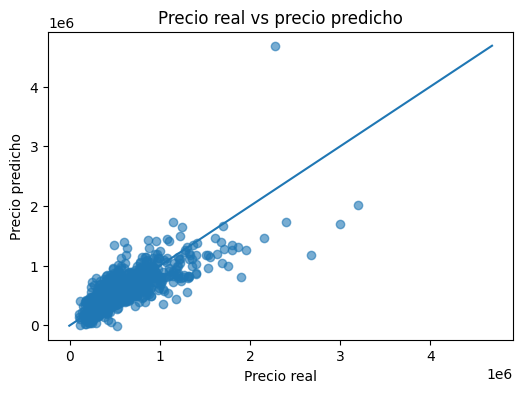

In [342]:
plt.figure(figsize=(6, 4))
plt.scatter(y_test, y_pred_test, alpha=0.6)
line_min = min(y_test.min(), y_pred_test.min())
line_max = max(y_test.max(), y_pred_test.max())
plt.plot([line_min, line_max], [line_min, line_max])
plt.xlabel('Precio real')
plt.ylabel('Precio predicho')
plt.title('Precio real vs precio predicho')
plt.show()

La gráfica muestra una relación positiva entre los precios reales y los precios predichos, indicando que el modelo logra capturar parte de la tendencia general de los precios de las viviendas. La mayoría de las observaciones se concentra en los rangos de precios bajos y medios y se encuentra relativamente próxima a la línea de referencia. Sin embargo, a medida que aumenta el precio real, se observa una mayor dispersión entre los valores reales y predichos. También se identifican algunos casos extremos y una tendencia a subestimar determinadas viviendas de precio elevado. Esto indica que el modelo presenta mayores dificultades para representar correctamente los valores extremos del mercado.

**RESIDUALES**

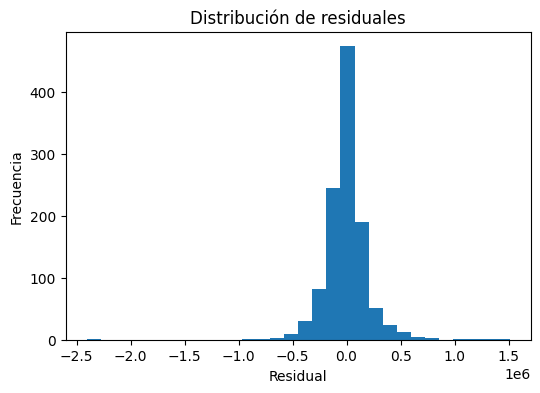

In [343]:
residuos = y_test - y_pred_test

plt.figure(figsize=(6, 4))
plt.hist(residuos, bins=30)
plt.title('Distribución de residuales')
plt.xlabel('Residual')
plt.ylabel('Frecuencia')
plt.show()

La distribución de los residuos se concentra principalmente alrededor de cero, lo que indica que para una gran parte de las viviendas las predicciones se encuentran relativamente próximas a los valores reales. Sin embargo, se observan colas hacia ambos lados y algunos residuos extremos, incluyendo errores de varios millones de unidades monetarias. Esto evidencia que, aunque el modelo presenta un comportamiento razonable para la mayoría de las observaciones, tiene dificultades para representar algunos casos particulares y valores extremos del precio.

**Residuales vs Prediccion**

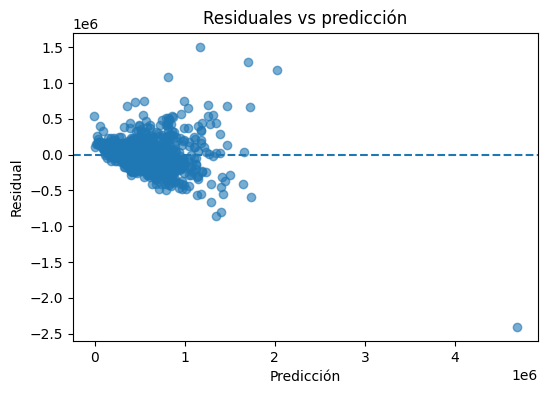

In [347]:
plt.figure(figsize=(6, 4))
plt.scatter(y_pred_test, residuos, alpha=0.6)
plt.axhline(0, linestyle='--')
plt.xlabel('Predicción')
plt.ylabel('Residual')
plt.title('Residuales vs predicción')
plt.show()

La gráfica muestra que los residuos se concentran alrededor de cero, principalmente en los rangos de precios predichos bajos y medios. Aún así a medida que aumenta el precio predicho, también aumenta la dispersión de los residuos. Además, se identifican algunos valores extremos con errores elevados. Este comportamiento sugiere que la variabilidad de los errores no es constante a lo largo del rango de predicciones, lo que indica la posible presencia de heterocedasticidad y una mayor dificultad del modelo para predecir correctamente las viviendas de mayor valor.

# **PREDICCIONES CON CASOS NUEVOS**

Para comprobar la aplicación práctica del modelo, se realizaron predicciones sobre tres viviendas hipotéticas utilizando las mismas variables empleadas durante el entrenamiento. El modelo permite estimar el precio de una vivienda a partir de sus características, aplicando automáticamente el preprocesamiento definido en el pipeline.

In [348]:
nuevas_viviendas = pd.DataFrame({
    'area_construida_m2': [60, 95, 140],
    'm2_por_habitacion': [30, 31.7, 35],
    'banos': [1, 2, 2],
    'habitaciones': [2, 3, 4],
    'pisos': [1, 2, 2],
    'zona': ['Sur', 'Seattle', 'Norte'],
    'anio_construccion': [2005, 2015, 2020],
    'vista': [1, 2, 3]
})

nuevas_viviendas['precio_estimado'] = model_final.predict(nuevas_viviendas)

nuevas_viviendas

,area_construida_m2,m2_por_habitacion,banos,habitaciones,pisos,zona,anio_construccion,vista,precio_estimado
0,60,30.0,1,2,1,Sur,2005,1,86060.154455
1,95,31.7,2,3,2,Seattle,2015,2,427891.883930
2,140,35.0,2,4,2,Norte,2020,3,414938.822936


Se aplicó el modelo final a tres viviendas con características nuevas para obtener una estimación de su precio. Los precios estimados fueron 86.060,15, 427.891,88 y 414.938,82.
La segunda vivienda obtuvo el precio estimado más alto (427.891,88), mientras que la primera presentó el precio más bajo (86.060,15). La tercera vivienda, a pesar de contar con una mayor área construida y más habitaciones que la segunda, obtuvo un precio estimado ligeramente inferior. Esto muestra que la predicción depende de la combinación de todas las características introducidas en el modelo, y no de una sola variable.
En conjunto, estas predicciones permiten observar cómo el modelo utiliza las características de nuevas viviendas para generar estimaciones de precio.

# **CONCLUSIONES**

El proyecto permitió desarrollar un modelo de Regresión Lineal para estimar el precio de las viviendas a partir de sus características físicas, de ubicación y de vista. Durante el proceso se realizó la preparación de los datos, el tratamiento de valores faltantes, el escalado de variables y la codificación de las variables categóricas, manteniendo el preprocesamiento integrado dentro de un Pipeline.

En el tratamiento de valores faltantes se compararon las estrategias de media, mediana y KNN, obteniendo resultados similares. Sin embargo, KNNImputer con 5 vecinos presentó el mejor desempeño, por lo que fue seleccionado para el modelo final.

Posteriormente, se compararon StandardScaler, MinMaxScaler y RobustScaler utilizando KNN como imputador. Los tres métodos obtuvieron exactamente el mismo desempeño predictivo, por lo que se seleccionó StandardScaler por simplicidad y porque facilita la interpretación de los coeficientes.

El análisis de los coeficientes mostró que area_construida_m2 es la variable con mayor asociación positiva con el precio, mientras que variables como habitaciones, m2_por_habitacion y algunas categorías de zona presentan asociaciones negativas dentro del modelo. Estos resultados representan asociaciones estimadas y no efectos causales.

El análisis de errores mostró que el modelo logra capturar la tendencia general de los precios, pero presenta mayor dispersión y errores más elevados en viviendas de precios altos. La distribución de residuos se concentra alrededor de cero, aunque existen algunos valores extremos, y la gráfica de residuos frente a las predicciones sugiere una posible heterocedasticidad.

Finalmente, las predicciones sobre nuevas viviendas demostraron la aplicación práctica del modelo, obteniendo estimaciones diferentes según la combinación de características de cada propiedad. En conjunto, el proyecto permitió pasar desde la preparación y exploración de los datos hasta la construcción, evaluación, interpretación y aplicación de un modelo de predicción de precios.